# Fake News Detection: TF-IDF vs BERT vs DistilBERT (Frozen vs Fine-tuned)

**Research Question:** Does fine-tuning outperform freezing for fake news detection, and does the larger BERT justify its computational cost over DistilBERT?

**Dataset:** GonzaloA/fake_news (CC BY 4.0)

**Models compared:**
- TF-IDF + Logistic Regression (baseline)
- DistilBERT — Frozen encoder
- DistilBERT — Fine-tuned
- BERT — Frozen encoder
- BERT — Fine-tuned

---

## Step 1 — Install and Import

In [1]:
!pip install datasets transformers torch scikit-learn seaborn matplotlib pandas -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import random
import re
import time
import warnings
warnings.filterwarnings('ignore')

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    DistilBertTokenizer, DistilBertForSequenceClassification,
    BertTokenizer, BertForSequenceClassification,
    get_linear_schedule_with_warmup
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device} | Seed: {SEED}')

Device: cuda | Seed: 42


## Step 2 — Load and Clean Data

In [3]:

dataset = load_dataset('GonzaloA/fake_news')

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_train_raw = pd.DataFrame(dataset['train'])
df_test_raw  = pd.DataFrame(dataset['test'])

for df in [df_train_raw, df_test_raw]:
    df['text'] = df['text'].apply(clean_text)

df_train_raw = df_train_raw.dropna(subset=['text'])
df_test_raw  = df_test_raw.dropna(subset=['text'])
df_train_raw = df_train_raw[df_train_raw['text'].str.len() > 10].drop_duplicates(subset=['text'])
df_test_raw  = df_test_raw[df_test_raw['text'].str.len() > 10].drop_duplicates(subset=['text'])

df_train_raw = df_train_raw.sample(n=10000, random_state=SEED).reset_index(drop=True)

print(f'Train: {len(df_train_raw):,} | Test: {len(df_test_raw):,}')
print('Class distribution (train):')
print(df_train_raw['label'].value_counts())

README.md:   0%|          | 0.00/6.73k [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


dataset_infos.json:   0%|          | 0.00/1.03k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/38.8M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/13.0M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/13.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/24353 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/8117 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/8117 [00:00<?, ? examples/s]

Train: 10,000 | Test: 8,101
Class distribution (train):
label
1    5467
0    4533
Name: count, dtype: int64


## Step 3 — Data Exploration

Average length per class:
label_str
FAKE    424.0
REAL    386.0
Name: text_length, dtype: float64


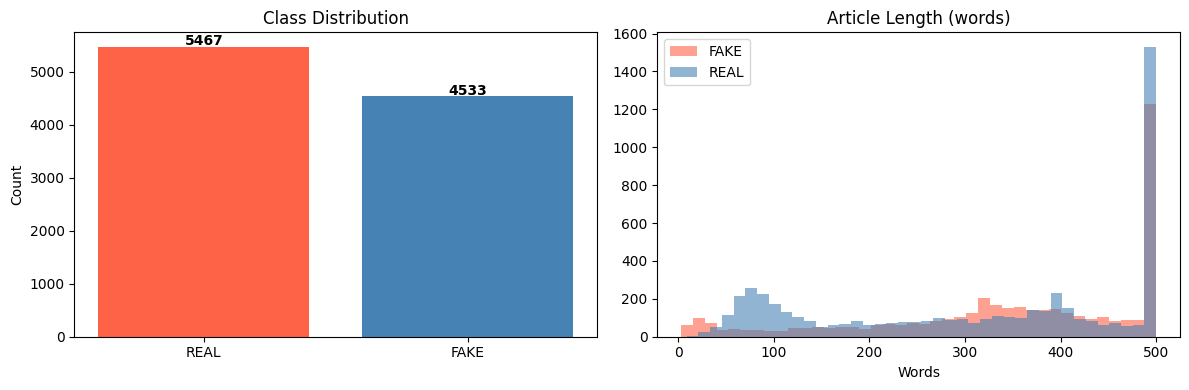


FAKE example:
if i were us district judge andrew hanen i d be keeping these guys close bythe injunction that has blocked president barack obama s executive amnesty will remain in place following the ruling of a federal judge tuesday night in this texas border cityin a late night ruling us district judge andrew ha

REAL example:
washington reuters president donald trump maintains his support of republican house leaders healthcare plan us health secretary tom price said on friday adding that the proposed measure tackles key issues important to the president the presidents very supportive of this plan thinks that it addresses


In [4]:
label_map = {0: 'FAKE', 1: 'REAL'}
df_train_raw['label_str']   = df_train_raw['label'].map(label_map)
df_train_raw['text_length'] = df_train_raw['text'].apply(lambda x: len(x.split()))

print('Average length per class:')
print(df_train_raw.groupby('label_str')['text_length'].mean().round(0))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df_train_raw['label_str'].value_counts()
axes[0].bar(counts.index, counts.values, color=['tomato', 'steelblue'])
axes[0].set_title('Class Distribution'); axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

axes[1].hist(df_train_raw[df_train_raw['label']==0]['text_length'].clip(upper=500),
             bins=40, alpha=0.6, label='FAKE', color='tomato')
axes[1].hist(df_train_raw[df_train_raw['label']==1]['text_length'].clip(upper=500),
             bins=40, alpha=0.6, label='REAL', color='steelblue')
axes[1].set_title('Article Length (words)'); axes[1].set_xlabel('Words'); axes[1].legend()
plt.tight_layout(); plt.savefig('data_exploration.png', dpi=150); plt.show()

print('\nFAKE example:')
print(df_train_raw[df_train_raw['label']==0]['text'].iloc[0][:300])
print('\nREAL example:')
print(df_train_raw[df_train_raw['label']==1]['text'].iloc[0][:300])

df_train_raw = df_train_raw.drop(columns=['label_str', 'text_length'])

## Step 4 — Splits

In [5]:
df_train_final, df_val = train_test_split(
    df_train_raw, test_size=0.10, random_state=SEED, stratify=df_train_raw['label']
)

X_train = df_train_final['text'].tolist(); y_train = df_train_final['label'].tolist()
X_val   = df_val['text'].tolist();         y_val   = df_val['label'].tolist()
X_test  = df_test_raw['text'].tolist();    y_test  = df_test_raw['label'].tolist()

print(f'Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}')

Train: 9,000 | Val: 1,000 | Test: 8,101


## Step 5 — Baseline: TF-IDF + Logistic Regression

=== TF-IDF + Logistic Regression — TEST ===
Accuracy : 0.9680 | F1: 0.9679
Train time: 20.9s | Inference: 0.008s
              precision    recall  f1-score   support

        FAKE       0.96      0.97      0.97      3768
        REAL       0.97      0.97      0.97      4333

    accuracy                           0.97      8101
   macro avg       0.97      0.97      0.97      8101
weighted avg       0.97      0.97      0.97      8101



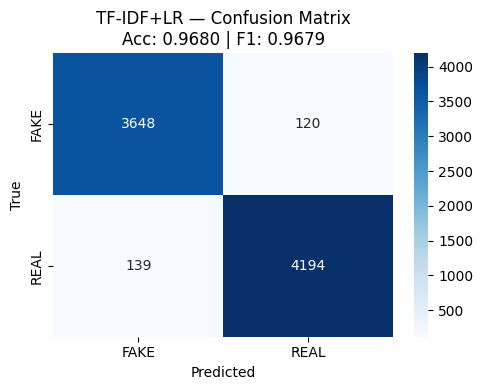

In [6]:
t0 = time.time()

vectorizer = TfidfVectorizer(max_features=50000, ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf   = vectorizer.transform(X_val)
X_test_tfidf  = vectorizer.transform(X_test)

tfidf_model = LogisticRegression(max_iter=1000, C=1.0, random_state=SEED)
tfidf_model.fit(X_train_tfidf, y_train)

train_time_tfidf = time.time() - t0

t1 = time.time()
tfidf_test_preds = tfidf_model.predict(X_test_tfidf)
inference_time_tfidf = time.time() - t1

tfidf_test_acc = accuracy_score(y_test, tfidf_test_preds)
tfidf_test_f1  = f1_score(y_test, tfidf_test_preds, average='macro')

print('=== TF-IDF + Logistic Regression — TEST ===')
print(f'Accuracy : {tfidf_test_acc:.4f} | F1: {tfidf_test_f1:.4f}')
print(f'Train time: {train_time_tfidf:.1f}s | Inference: {inference_time_tfidf:.3f}s')
print(classification_report(y_test, tfidf_test_preds, target_names=['FAKE', 'REAL']))

cm = confusion_matrix(y_test, tfidf_test_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['FAKE','REAL'], yticklabels=['FAKE','REAL'])
plt.title(f'TF-IDF+LR — Confusion Matrix\nAcc: {tfidf_test_acc:.4f} | F1: {tfidf_test_f1:.4f}')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout(); plt.savefig('tfidf_confusion.png', dpi=150); plt.show()

## Helper Functions (used by all Transformer models)

In [7]:
class FakeNewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts; self.labels = labels
        self.tokenizer = tokenizer; self.max_length = max_length
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(self.texts[idx], max_length=self.max_length,
                             padding='max_length', truncation=True, return_tensors='pt')
        return {'input_ids': enc['input_ids'].squeeze(),
                'attention_mask': enc['attention_mask'].squeeze(),
                'label': torch.tensor(self.labels[idx], dtype=torch.long)}

def train_epoch(model, loader, optimizer, scheduler):
    model.train()
    total_loss, all_preds, all_labels = 0, [], []
    for batch in loader:
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        lbls = batch['label'].to(device)
        optimizer.zero_grad()
        out = model(input_ids=ids, attention_mask=mask, labels=lbls)
        out.loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        total_loss += out.loss.item()
        all_preds.extend(torch.argmax(out.logits, dim=1).cpu().numpy())
        all_labels.extend(lbls.cpu().numpy())
    return total_loss / len(loader), accuracy_score(all_labels, all_preds)

def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            out  = model(input_ids=ids, attention_mask=mask)
            all_preds.extend(torch.argmax(out.logits, dim=1).cpu().numpy())
            all_labels.extend(batch['label'].numpy())
    return (accuracy_score(all_labels, all_preds),
            f1_score(all_labels, all_preds, average='macro'),
            all_preds, all_labels)

def train_model(model, tokenizer, model_name, frozen=False,
                epochs=3, batch_size=16, lr=2e-5, max_length=256):
    """
    Train a transformer model and return results + timing + memory.
    frozen=True: freeze encoder, train only the classification head.
    frozen=False: fine-tune all parameters.
    """
    if frozen:
        for name, param in model.named_parameters():
            if 'classifier' not in name and 'pre_classifier' not in name:
                param.requires_grad = False
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f'Frozen — trainable params: {trainable:,}')
    else:
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f'Fine-tuned — trainable params: {trainable:,}')

    train_loader = DataLoader(FakeNewsDataset(X_train, y_train, tokenizer, max_length),
                              batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(FakeNewsDataset(X_val,   y_val,   tokenizer, max_length),
                              batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(FakeNewsDataset(X_test,  y_test,  tokenizer, max_length),
                              batch_size=batch_size, shuffle=False)

    optimizer   = AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                        lr=lr, weight_decay=0.01)
    total_steps = len(train_loader) * epochs
    scheduler   = get_linear_schedule_with_warmup(optimizer,
                      num_warmup_steps=int(total_steps * 0.1),
                      num_training_steps=total_steps)

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    best_val_f1, best_state, patience = 0.0, None, 0
    t0 = time.time()

    for epoch in range(epochs):
        loss, train_acc       = train_epoch(model, train_loader, optimizer, scheduler)
        val_acc, val_f1, _, _ = evaluate(model, val_loader)
        print(f'  Epoch {epoch+1}/{epochs} | Loss: {loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f} | F1: {val_f1:.4f}')
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state  = {k: v.clone() for k, v in model.state_dict().items()}
            patience = 0
        else:
            patience += 1
            if patience >= 2: print('  --> Early stopping.'); break

    train_time = time.time() - t0

    model.load_state_dict(best_state)
    t1 = time.time()
    test_acc, test_f1, test_preds, test_labels = evaluate(model, test_loader)
    inference_time = time.time() - t1

    gpu_mem = 0
    if torch.cuda.is_available():
        gpu_mem = torch.cuda.max_memory_allocated() / 1e9  # in GB

    total_params = sum(p.numel() for p in model.parameters()) / 1e6  # in M

    print(f'\n  TEST — Acc: {test_acc:.4f} | F1: {test_f1:.4f}')
    print(f'  Train time: {train_time:.1f}s | Inference: {inference_time:.2f}s | GPU mem: {gpu_mem:.2f}GB | Params: {total_params:.1f}M')

    return {
        'model_name'    : model_name,
        'accuracy'      : round(test_acc, 4),
        'f1'            : round(test_f1, 4),
        'train_time_s'  : round(train_time, 1),
        'inference_time_s': round(inference_time, 3),
        'gpu_mem_gb'    : round(gpu_mem, 2),
        'params_M'      : round(total_params, 1),
        'test_preds'    : test_preds,
        'test_labels'   : test_labels
    }

print('Helper functions ready.')

Helper functions ready.


## Step 6 — DistilBERT Frozen

=== DistilBERT — Frozen ===


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Frozen — trainable params: 592,130
  Epoch 1/3 | Loss: 0.4885 | Train: 0.8159 | Val: 0.8820 | F1: 0.8799
  Epoch 2/3 | Loss: 0.2770 | Train: 0.9057 | Val: 0.8940 | F1: 0.8923
  Epoch 3/3 | Loss: 0.2499 | Train: 0.9114 | Val: 0.9050 | F1: 0.9038

  TEST — Acc: 0.9124 | F1: 0.9117
  Train time: 266.6s | Inference: 72.00s | GPU mem: 0.84GB | Params: 67.0M


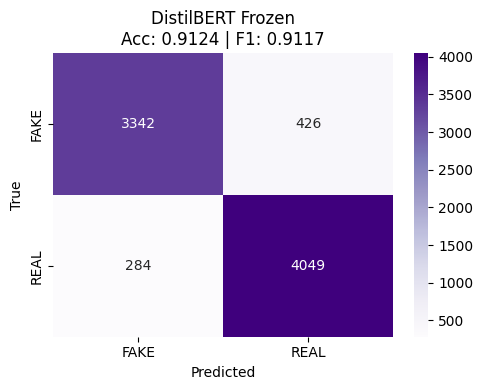

In [8]:
print('=== DistilBERT — Frozen ===')
tokenizer_distil = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
model_distil_frozen = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=2, ignore_mismatched_sizes=True
).to(device)

results_distil_frozen = train_model(
    model_distil_frozen, tokenizer_distil,
    model_name='DistilBERT Frozen', frozen=True
)

cm = confusion_matrix(results_distil_frozen['test_labels'], results_distil_frozen['test_preds'])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['FAKE','REAL'], yticklabels=['FAKE','REAL'])
plt.title(f'DistilBERT Frozen\nAcc: {results_distil_frozen["accuracy"]} | F1: {results_distil_frozen["f1"]}')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout(); plt.savefig('distilbert_frozen_confusion.png', dpi=150); plt.show()

## Step 7 — DistilBERT Fine-tuned

=== DistilBERT — Fine-tuned ===


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fine-tuned — trainable params: 66,955,010
  Epoch 1/3 | Loss: 0.1318 | Train: 0.9489 | Val: 0.9760 | F1: 0.9758
  Epoch 2/3 | Loss: 0.0346 | Train: 0.9896 | Val: 0.9770 | F1: 0.9768
  Epoch 3/3 | Loss: 0.0135 | Train: 0.9958 | Val: 0.9770 | F1: 0.9768

  TEST — Acc: 0.9863 | F1: 0.9862
  Train time: 711.4s | Inference: 69.04s | GPU mem: 2.76GB | Params: 67.0M


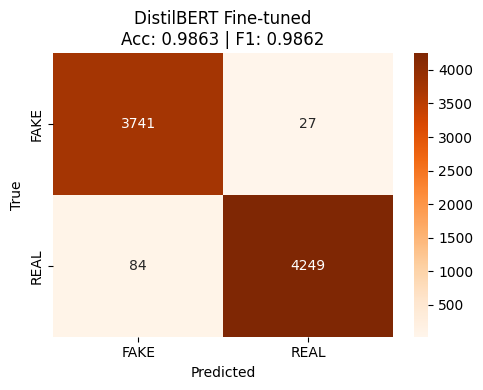

In [9]:
print('=== DistilBERT — Fine-tuned ===')
model_distil_ft = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=2, ignore_mismatched_sizes=True
).to(device)

results_distil_ft = train_model(
    model_distil_ft, tokenizer_distil,
    model_name='DistilBERT Fine-tuned', frozen=False
)

cm = confusion_matrix(results_distil_ft['test_labels'], results_distil_ft['test_preds'])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['FAKE','REAL'], yticklabels=['FAKE','REAL'])
plt.title(f'DistilBERT Fine-tuned\nAcc: {results_distil_ft["accuracy"]} | F1: {results_distil_ft["f1"]}')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout(); plt.savefig('distilbert_ft_confusion.png', dpi=150); plt.show()

## Step 8 — BERT Frozen

=== BERT — Frozen ===


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Frozen — trainable params: 1,538
  Epoch 1/3 | Loss: 0.6791 | Train: 0.5602 | Val: 0.6010 | F1: 0.4835
  Epoch 2/3 | Loss: 0.6508 | Train: 0.6388 | Val: 0.6130 | F1: 0.5027
  Epoch 3/3 | Loss: 0.6381 | Train: 0.6668 | Val: 0.6860 | F1: 0.6304

  TEST — Acc: 0.6803 | F1: 0.6321
  Train time: 495.2s | Inference: 131.51s | GPU mem: 2.19GB | Params: 109.5M


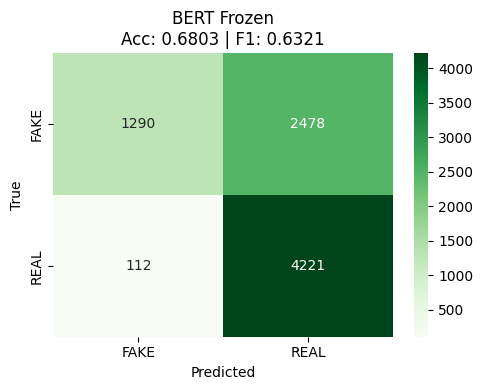

In [10]:
print('=== BERT — Frozen ===')
tokenizer_bert = BertTokenizer.from_pretrained('bert-base-uncased')
model_bert_frozen = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased', num_labels=2, ignore_mismatched_sizes=True
).to(device)

results_bert_frozen = train_model(
    model_bert_frozen, tokenizer_bert,
    model_name='BERT Frozen', frozen=True
)

cm = confusion_matrix(results_bert_frozen['test_labels'], results_bert_frozen['test_preds'])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['FAKE','REAL'], yticklabels=['FAKE','REAL'])
plt.title(f'BERT Frozen\nAcc: {results_bert_frozen["accuracy"]} | F1: {results_bert_frozen["f1"]}')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout(); plt.savefig('bert_frozen_confusion.png', dpi=150); plt.show()

## Step 9 — BERT Fine-tuned

=== BERT — Fine-tuned ===


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fine-tuned — trainable params: 109,483,778
  Epoch 1/3 | Loss: 0.1462 | Train: 0.9396 | Val: 0.9700 | F1: 0.9699
  Epoch 2/3 | Loss: 0.0357 | Train: 0.9898 | Val: 0.9770 | F1: 0.9769
  Epoch 3/3 | Loss: 0.0136 | Train: 0.9962 | Val: 0.9820 | F1: 0.9818

  TEST — Acc: 0.9846 | F1: 0.9845
  Train time: 1383.8s | Inference: 131.35s | GPU mem: 5.75GB | Params: 109.5M


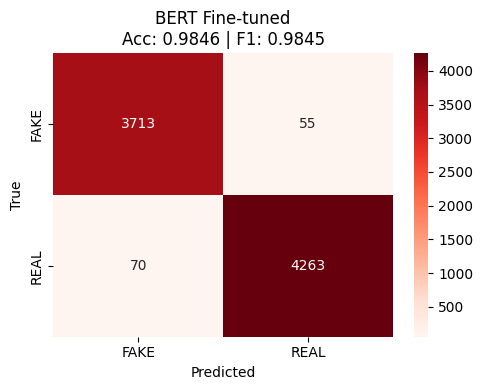

In [11]:
print('=== BERT — Fine-tuned ===')
model_bert_ft = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased', num_labels=2, ignore_mismatched_sizes=True
).to(device)

results_bert_ft = train_model(
    model_bert_ft, tokenizer_bert,
    model_name='BERT Fine-tuned', frozen=False
)

cm = confusion_matrix(results_bert_ft['test_labels'], results_bert_ft['test_preds'])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['FAKE','REAL'], yticklabels=['FAKE','REAL'])
plt.title(f'BERT Fine-tuned\nAcc: {results_bert_ft["accuracy"]} | F1: {results_bert_ft["f1"]}')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout(); plt.savefig('bert_ft_confusion.png', dpi=150); plt.show()

## Step 10 — Full Comparison (Accuracy, F1, Runtime, Memory)

                Model  Accuracy       F1   Train(s)  Inference(s)  GPU(GB)  Params(M)
          TF-IDF + LR  0.968029 0.967883   20.86336      0.007966     0.00        0.0
    DistilBERT Frozen  0.912400 0.911700  266.60000     72.000000     0.84       67.0
DistilBERT Fine-tuned  0.986300 0.986200  711.40000     69.038000     2.76       67.0
          BERT Frozen  0.680300 0.632100  495.20000    131.510000     2.19      109.5
      BERT Fine-tuned  0.984600 0.984500 1383.80000    131.348000     5.75      109.5


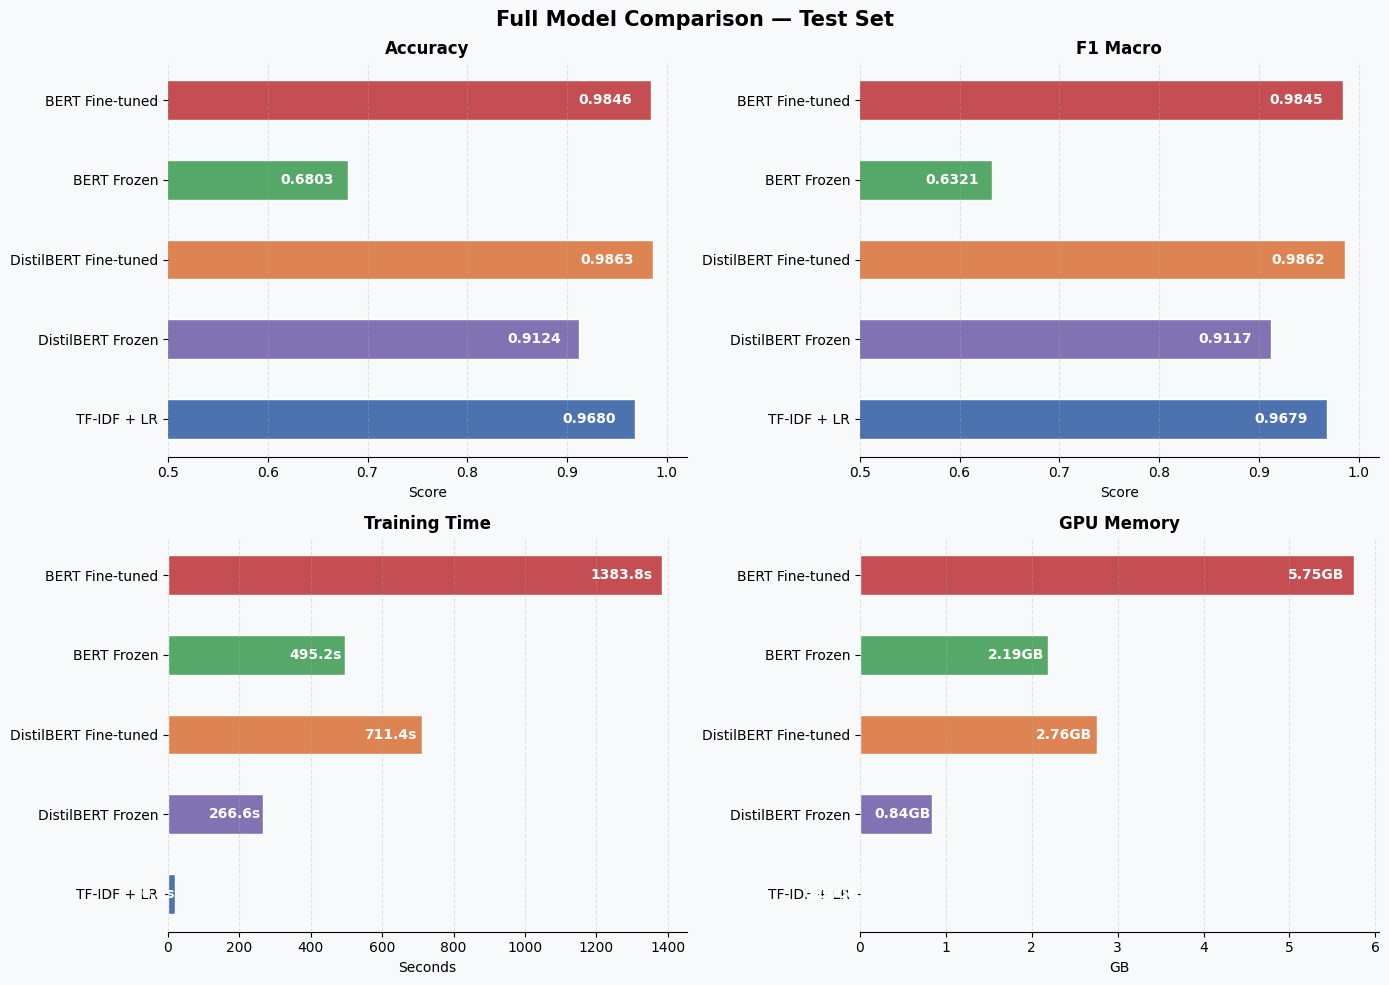

In [12]:
all_results = [
    {'Model': 'TF-IDF + LR',         'Accuracy': tfidf_test_acc,                    'F1': tfidf_test_f1,
     'Train(s)': train_time_tfidf,   'Inference(s)': inference_time_tfidf,          'GPU(GB)': 0,
     'Params(M)': 0},
    {'Model': 'DistilBERT Frozen',    'Accuracy': results_distil_frozen['accuracy'], 'F1': results_distil_frozen['f1'],
     'Train(s)': results_distil_frozen['train_time_s'], 'Inference(s)': results_distil_frozen['inference_time_s'],
     'GPU(GB)': results_distil_frozen['gpu_mem_gb'],    'Params(M)': results_distil_frozen['params_M']},
    {'Model': 'DistilBERT Fine-tuned','Accuracy': results_distil_ft['accuracy'],     'F1': results_distil_ft['f1'],
     'Train(s)': results_distil_ft['train_time_s'],     'Inference(s)': results_distil_ft['inference_time_s'],
     'GPU(GB)': results_distil_ft['gpu_mem_gb'],        'Params(M)': results_distil_ft['params_M']},
    {'Model': 'BERT Frozen',          'Accuracy': results_bert_frozen['accuracy'],   'F1': results_bert_frozen['f1'],
     'Train(s)': results_bert_frozen['train_time_s'],   'Inference(s)': results_bert_frozen['inference_time_s'],
     'GPU(GB)': results_bert_frozen['gpu_mem_gb'],      'Params(M)': results_bert_frozen['params_M']},
    {'Model': 'BERT Fine-tuned',      'Accuracy': results_bert_ft['accuracy'],       'F1': results_bert_ft['f1'],
     'Train(s)': results_bert_ft['train_time_s'],       'Inference(s)': results_bert_ft['inference_time_s'],
     'GPU(GB)': results_bert_ft['gpu_mem_gb'],          'Params(M)': results_bert_ft['params_M']},
]
df_results = pd.DataFrame(all_results)
print(df_results.to_string(index=False))

models  = df_results['Model'].tolist()
colors  = ['#4C72B0', '#8172B3', '#DD8452', '#55A868', '#C44E52']

fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor='#f8f9fa')
fig.suptitle('Full Model Comparison — Test Set', fontsize=15, fontweight='bold')

def hbar(ax, values, title, xlabel, color_list, annotate_fmt='{:.4f}'):
    bars = ax.barh(models, values, color=color_list, height=0.5, edgecolor='white')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel(xlabel)
    ax.spines[['top','right','left']].set_visible(False)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.set_facecolor('#f8f9fa')
    for bar, val in zip(bars, values):
        ax.text(bar.get_width() * 0.98, bar.get_y() + bar.get_height()/2,
                annotate_fmt.format(val), ha='right', va='center',
                fontsize=10, fontweight='bold', color='white')

hbar(axes[0,0], df_results['Accuracy'].tolist(), 'Accuracy', 'Score', colors)
axes[0,0].set_xlim(0.5, 1.02)

hbar(axes[0,1], df_results['F1'].tolist(), 'F1 Macro', 'Score', colors)
axes[0,1].set_xlim(0.5, 1.02)

hbar(axes[1,0], df_results['Train(s)'].tolist(), 'Training Time', 'Seconds', colors, '{:.1f}s')

hbar(axes[1,1], df_results['GPU(GB)'].tolist(), 'GPU Memory', 'GB', colors, '{:.2f}GB')

plt.tight_layout()
plt.savefig('full_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 12 — Error Analysis

In [13]:
label_map = {0: 'FAKE', 1: 'REAL'}
df_errors = pd.DataFrame({
    'text'             : X_test,
    'true_label'       : y_test,
    'tfidf_pred'       : tfidf_test_preds,
    'distilbert_pred'  : results_distil_ft['test_preds'],
    'bert_pred'        : results_bert_ft['test_preds']
})

for col in ['true_label', 'tfidf_pred', 'distilbert_pred', 'bert_pred']:
    df_errors[col+'_str'] = df_errors[col].map(label_map)

# All correct
all_correct = df_errors[
    (df_errors['true_label'] == df_errors['tfidf_pred']) &
    (df_errors['true_label'] == df_errors['distilbert_pred']) &
    (df_errors['true_label'] == df_errors['bert_pred'])]

# All wrong
all_wrong = df_errors[
    (df_errors['true_label'] != df_errors['tfidf_pred']) &
    (df_errors['true_label'] != df_errors['distilbert_pred']) &
    (df_errors['true_label'] != df_errors['bert_pred'])]

# Only TF-IDF wrong
only_tfidf_wrong = df_errors[
    (df_errors['true_label'] != df_errors['tfidf_pred']) &
    (df_errors['true_label'] == df_errors['distilbert_pred']) &
    (df_errors['true_label'] == df_errors['bert_pred'])]

# Transformers right, TF-IDF wrong
transformers_win = df_errors[
    (df_errors['true_label'] != df_errors['tfidf_pred']) &
    (df_errors['true_label'] == df_errors['distilbert_pred']) &
    (df_errors['true_label'] == df_errors['bert_pred'])]

print(f'All correct              : {len(all_correct)}')
print(f'Only TF-IDF wrong        : {len(only_tfidf_wrong)}')
print(f'All wrong (hard examples): {len(all_wrong)}')

print('\n--- Only TF-IDF wrong (both Transformers right) ---')
for _, row in only_tfidf_wrong.head(3).iterrows():
    print(f'True: {row["true_label_str"]} | TF-IDF: {row["tfidf_pred_str"]} | DistilBERT: {row["distilbert_pred_str"]} | BERT: {row["bert_pred_str"]}')
    print(row['text'][:200])
    print('-'*50)

print('\n--- All models wrong ---')
for _, row in all_wrong.head(3).iterrows():
    print(f'True: {row["true_label_str"]} | TF-IDF: {row["tfidf_pred_str"]} | DistilBERT: {row["distilbert_pred_str"]} | BERT: {row["bert_pred_str"]}')
    print(row['text'][:200])
    print('-'*50)

All correct              : 7778
Only TF-IDF wrong        : 163
All wrong (hard examples): 62

--- Only TF-IDF wrong (both Transformers right) ---
True: FAKE | TF-IDF: REAL | DistilBERT: FAKE | BERT: FAKE
last majority white election minorities to give democrats white house through paul bedard washington examiner november this may be the last year that a republican will be elected president as the grow
--------------------------------------------------
True: FAKE | TF-IDF: REAL | DistilBERT: FAKE | BERT: FAKE
the electronic war has not yet begun the jv teamthe islamic state s hacking division has published personal details including phone numbers of the heads of the cia fbi and the national security agency
--------------------------------------------------
True: REAL | TF-IDF: FAKE | DistilBERT: REAL | BERT: REAL
how they could steal the election from trump even if he is announced the winner next tuesday october at am how they could steal the election from trump even if he is announced 

## Step 13 — Save Results and Download

In [14]:
df_results.to_csv('final_results.csv', index=False)
print('=== FINAL RESULTS ===')
print(df_results[['Model','Accuracy','F1','Train(s)','GPU(GB)','Params(M)']].to_string(index=False))
print(f'\nSeed: {SEED} | Epochs: 3 | LR: 2e-5 | MaxLen: 256 | Batch: 16')

from google.colab import files
for f in ['final_results.csv',
          'data_exploration.png', 'full_comparison.png',
          'tfidf_confusion.png', 'distilbert_frozen_confusion.png',
          'distilbert_ft_confusion.png', 'bert_frozen_confusion.png',
          'bert_ft_confusion.png']:
    files.download(f)
    print(f'Downloaded: {f}')

=== FINAL RESULTS ===
                Model  Accuracy       F1   Train(s)  GPU(GB)  Params(M)
          TF-IDF + LR  0.968029 0.967883   20.86336     0.00        0.0
    DistilBERT Frozen  0.912400 0.911700  266.60000     0.84       67.0
DistilBERT Fine-tuned  0.986300 0.986200  711.40000     2.76       67.0
          BERT Frozen  0.680300 0.632100  495.20000     2.19      109.5
      BERT Fine-tuned  0.984600 0.984500 1383.80000     5.75      109.5

Seed: 42 | Epochs: 3 | LR: 2e-5 | MaxLen: 256 | Batch: 16


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: final_results.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: bert_frozen_confusion.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: bert_ft_confusion.png
